# Iteration 2 — Expanded Dataset Training

Trains **YOLO26n**, **RT-DETR-l**, and **RF-DETR Base** for **100 epochs** each
on the expanded dataset (original + real-world wallet + custom sunglasses/wallet images).

Run `clean.ipynb` merge cells before running this notebook.

## Data Preprocessing

This section audits dataset quality, removes near-duplicates, checks class balance, verifies train/val/test splits, applies letterbox resizing to 640x640, and augments training images — all before model training begins.

In [17]:
%pip install imagehash albumentations -q

from pathlib import Path
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import cv2

# ── Configuration ─────────────────────────────────────────────────────────────
DATASET_PATH = Path('../data')
CLASSES = ['Sunglasses', 'Keys', 'Wallet']
SPLITS = ['train', 'valid', 'test']
IMG_SIZE = 640

Note: you may need to restart the kernel to use updated packages.


### Step 1: Dataset Quality Audit

Count images per split and class, detect near-duplicates via perceptual hashing, identify corrupted images, and flag missing or empty annotation files.

In [18]:
import imagehash

print('=' * 60)
print('STEP 1: Dataset Quality Audit')
print('=' * 60)

# 1a. Image counts per split
print('\n--- Images per split ---')
for split in SPLITS:
    imgs = [f for f in (DATASET_PATH / split / 'images').glob('*')
            if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    print(f'  {split}: {len(imgs)} images')

# 1b. Instance counts per class per split
print('\n--- Instances per class per split ---')
for split in SPLITS:
    counts = Counter()
    for lbl in (DATASET_PATH / split / 'labels').glob('*.txt'):
        for line in lbl.read_text().strip().splitlines():
            if line.strip():
                cls_id = int(line.split()[0])
                if cls_id < len(CLASSES):
                    counts[CLASSES[cls_id]] += 1
    print(f'  {split}: {dict(counts)}')

# 1c. Near-duplicate detection via perceptual hashing
print('\n--- Near-duplicate detection ---')
hash_map = {}
duplicates = []
for split in SPLITS:
    for img_path in sorted((DATASET_PATH / split / 'images').glob('*')):
        if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
            continue
        try:
            h = str(imagehash.phash(Image.open(img_path)))
            if h in hash_map:
                duplicates.append((hash_map[h], (split, img_path.name)))
            else:
                hash_map[h] = (split, img_path.name)
        except Exception:
            pass  # handled in corrupted check below

if duplicates:
    print(f'  Found {len(duplicates)} near-duplicate pair(s):')
    for orig, dup in duplicates[:10]:
        print(f'    {orig[0]}/{orig[1]}  <->  {dup[0]}/{dup[1]}')
    if len(duplicates) > 10:
        print(f'    ... and {len(duplicates) - 10} more')
else:
    print('  No near-duplicates detected.')

# 1d. Corrupted / unreadable images
print('\n--- Corrupted images ---')
corrupted = []
for split in SPLITS:
    for img_path in sorted((DATASET_PATH / split / 'images').glob('*')):
        if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
            continue
        try:
            with Image.open(img_path) as im:
                im.verify()
        except Exception as e:
            corrupted.append(f'{split}/{img_path.name}: {e}')

if corrupted:
    print(f'  Found {len(corrupted)} corrupted image(s):')
    for c in corrupted:
        print(f'    {c}')
else:
    print('  All images readable.')

# 1e. Missing or empty annotation files
print('\n--- Missing / empty annotations ---')
missing, empty = [], []
for split in SPLITS:
    imgs_dir = DATASET_PATH / split / 'images'
    labels_dir = DATASET_PATH / split / 'labels'
    for img_path in sorted(imgs_dir.glob('*')):
        if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
            continue
        lbl = labels_dir / (img_path.stem + '.txt')
        if not lbl.exists():
            missing.append(f'{split}/{img_path.name}')
        elif not lbl.read_text().strip():
            empty.append(f'{split}/{img_path.name}')

print(f'  Missing label files: {len(missing)}')
for m in missing[:5]:
    print(f'    {m}')
if len(missing) > 5:
    print(f'    ... and {len(missing) - 5} more')
print(f'  Empty label files (background / negative samples): {len(empty)}')
for e in empty[:5]:
    print(f'    {e}')
if len(empty) > 5:
    print(f'    ... and {len(empty) - 5} more')

print('\nStep 1 complete.')

STEP 1: Dataset Quality Audit

--- Images per split ---
  train: 4913 images
  valid: 289 images
  test: 232 images

--- Instances per class per split ---
  train: {'Keys': 2196, 'Sunglasses': 1507, 'Wallet': 2102}
  valid: {'Wallet': 159, 'Keys': 144, 'Sunglasses': 60}
  test: {'Wallet': 118, 'Keys': 130, 'Sunglasses': 40}

--- Near-duplicate detection ---
  Found 261 near-duplicate pair(s):
    train/00106210101918____1__516x640_jpg.rf.771c16aa57f7c1b9ffd62294fefb8a99.jpg  <->  train/00106210101918____1__516x640_jpg.rf.771c16aa57f7c1b9ffd62294fefb8a99_aug1.jpg
    train/01_124623c5-669a-473b-8647-756219f53661_1024x1024_jpg.rf.5c9e9cea0f169af6f9f600d3b3548a13.jpg  <->  train/01_124623c5-669a-473b-8647-756219f53661_1024x1024_jpg.rf.5c9e9cea0f169af6f9f600d3b3548a13_aug1.jpg
    train/01_jpg.rf.2afd52fd7b5cf9dc5ea816b0eca9d52c.jpg  <->  train/01_jpg.rf.2afd52fd7b5cf9dc5ea816b0eca9d52c_aug1.jpg
    train/0802_TopNav_Bags_Wallets_Mobile-2x_jpg.rf.b7246b1270fb9563d33e6260c6d34e8d.jpg  <->  

### Step 2: Near-Duplicate Removal

Remove one image from each near-duplicate pair detected in Step 1. This prevents the model from memorising repeated examples and ensures cleaner evaluation metrics. The **second** occurrence (the duplicate) is deleted along with its label file.

In [19]:
print('=' * 60)
print('STEP 2: Near-Duplicate Removal')
print('=' * 60)

removed = 0
kept_empty_removed = 0

for orig, dup in duplicates:
    dup_split, dup_name = dup
    img_path = DATASET_PATH / dup_split / 'images' / dup_name
    lbl_path = DATASET_PATH / dup_split / 'labels' / (Path(dup_name).stem + '.txt')

    if img_path.exists():
        img_path.unlink()
        removed += 1
    if lbl_path.exists():
        # Check if the label was empty (background sample)
        if not lbl_path.read_text().strip():
            kept_empty_removed += 1
        lbl_path.unlink()

print(f'  Removed {removed} duplicate images (and their labels).')
print(f'  Of those, {kept_empty_removed} had empty labels (background samples).')

# Recount after removal
print('\n--- Post-dedup image counts ---')
for split in SPLITS:
    imgs = [f for f in (DATASET_PATH / split / 'images').glob('*')
            if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    print(f'  {split}: {len(imgs)} images')

print('\n--- Post-dedup instances per class per split ---')
for split in SPLITS:
    counts = Counter()
    for lbl in (DATASET_PATH / split / 'labels').glob('*.txt'):
        for line in lbl.read_text().strip().splitlines():
            if line.strip():
                cls_id = int(line.split()[0])
                if cls_id < len(CLASSES):
                    counts[CLASSES[cls_id]] += 1
    print(f'  {split}: {dict(counts)}')

print('\nStep 2 complete.')

STEP 2: Near-Duplicate Removal
  Removed 261 duplicate images (and their labels).
  Of those, 0 had empty labels (background samples).

--- Post-dedup image counts ---
  train: 4656 images
  valid: 287 images
  test: 230 images

--- Post-dedup instances per class per split ---
  train: {'Keys': 2049, 'Sunglasses': 1431, 'Wallet': 2009}
  valid: {'Wallet': 159, 'Keys': 140, 'Sunglasses': 60}
  test: {'Wallet': 118, 'Keys': 126, 'Sunglasses': 40}

Step 2 complete.


### Step 3: Class Balance Check

Count bounding box instances per class across the full dataset. Flag any class whose count falls below 70% of the most-frequent class.

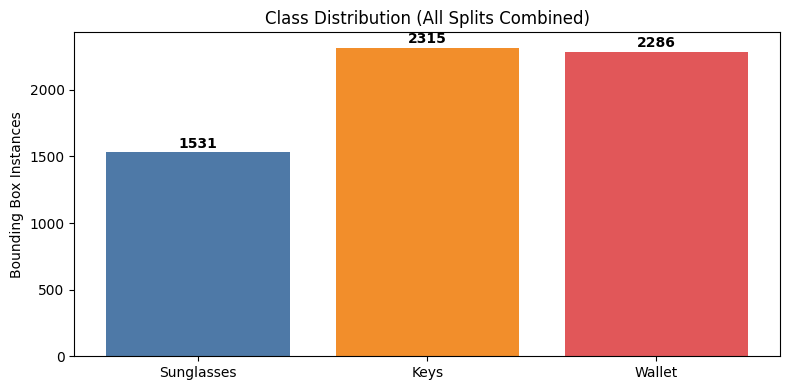

Class balance check (threshold: 70% of most frequent):
  Sunglasses: 1531 — LOW (< 1620)
  Keys: 2315 — OK
  Wallet: 2286 — OK

Step 2 complete.


In [20]:
# Count bounding box instances per class across all splits
total_counts = Counter()
for split in SPLITS:
    for lbl in (DATASET_PATH / split / 'labels').glob('*.txt'):
        for line in lbl.read_text().strip().splitlines():
            if line.strip():
                cls_id = int(line.split()[0])
                if cls_id < len(CLASSES):
                    total_counts[CLASSES[cls_id]] += 1

# Plot class distribution
counts_list = [total_counts.get(cls, 0) for cls in CLASSES]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(CLASSES, counts_list, color=['#4e79a7', '#f28e2b', '#e15759'])
ax.set_ylabel('Bounding Box Instances')
ax.set_title('Class Distribution (All Splits Combined)')
for bar, count in zip(bars, counts_list):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# Flag under-represented classes (< 70% of the most frequent)
max_count = max(counts_list)
threshold = 0.7 * max_count
print('Class balance check (threshold: 70% of most frequent):')
for cls, count in zip(CLASSES, counts_list):
    status = 'OK' if count >= threshold else f'LOW (< {threshold:.0f})'
    print(f'  {cls}: {count} — {status}')

print('\nStep 2 complete.')

### Step 4: Train / Val / Test Split Verification

Confirm the existing Roboflow splits are close to the standard 70/20/10 or 80/10/10 ratio. Warn if any split deviates by more than 5 percentage points.

In [21]:
# Count images per split
split_counts = {}
for split in SPLITS:
    imgs = [f for f in (DATASET_PATH / split / 'images').glob('*')
            if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    split_counts[split] = len(imgs)

total = sum(split_counts.values())
ratios = {s: c / total * 100 for s, c in split_counts.items()}

print('Split ratios:')
for split, count in split_counts.items():
    print(f'  {split:6s}: {count:5d} images ({ratios[split]:5.1f}%)')
print(f'  {"total":6s}: {total:5d} images')

# Check against standard targets
targets = [
    {'name': '70/10/20', 'train': 70, 'valid': 10, 'test': 20},
    {'name': '80/10/10', 'train': 80, 'valid': 10, 'test': 10},
]

print('\nDeviation from standard splits:')
for t in targets:
    deviations = {s: abs(ratios[s] - t[s]) for s in SPLITS}
    max_dev = max(deviations.values())
    status = 'OK' if max_dev < 5 else 'WARNING — significant deviation'
    print(f'  vs {t["name"]}: max deviation = {max_dev:.1f}% — {status}')

print('\nStep 3 complete.')

Split ratios:
  train :  4656 images ( 90.0%)
  valid :   287 images (  5.5%)
  test  :   230 images (  4.4%)
  total :  5173 images

Deviation from standard splits:
  vs 70/10/20: max deviation = 20.0% — WARNING — significant deviation
  vs 80/10/10: max deviation = 10.0% — WARNING — significant deviation

Step 3 complete.


### Step 5: Augmentation Pipeline

Apply data augmentations to the **training set only** to increase variety. Each training image gets 2 augmented copies with randomised brightness, flips, rotation, crop, blur, and colour jitter. Bounding boxes are transformed in sync.

In [22]:
import albumentations as A

# Save pre-augmentation image count for the final summary
pre_aug_train_count = len([f for f in (DATASET_PATH / 'train' / 'images').glob('*')
                           if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])

# Augmentation pipeline with bounding box support
transform = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, border_mode=cv2.BORDER_CONSTANT,
             value=(114, 114, 114), p=0.5),
    A.RandomResizedCrop(
        size=(IMG_SIZE, IMG_SIZE), scale=(0.8, 1.0), ratio=(0.9, 1.1), p=0.5),
    A.MotionBlur(blur_limit=7, p=0.3),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=30,
                         val_shift_limit=20, p=0.4),
], bbox_params=A.BboxParams(
    format='yolo', label_fields=['class_labels'], min_visibility=0.3))

NUM_AUG = 2  # augmented copies per original image
train_imgs = DATASET_PATH / 'train' / 'images'
train_lbls = DATASET_PATH / 'train' / 'labels'

# Only augment original images (skip any previously generated _aug files)
img_files = sorted([f for f in train_imgs.glob('*')
                    if f.suffix.lower() in ('.jpg', '.jpeg', '.png')
                    and '_aug' not in f.stem])

print(f'Augmenting {len(img_files)} training images ({NUM_AUG} copies each)...')
aug_count = 0

for idx, img_path in enumerate(img_files):
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Read YOLO annotations
    lbl_path = train_lbls / (img_path.stem + '.txt')
    bboxes, class_labels = [], []
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            parts = line.strip().split()
            if len(parts) >= 5:
                class_labels.append(int(parts[0]))
                bboxes.append([float(x) for x in parts[1:5]])

    if not bboxes:
        continue  # skip background images

    for i in range(NUM_AUG):
        try:
            result = transform(
                image=img_rgb, bboxes=bboxes, class_labels=class_labels)

            if not result['bboxes']:
                continue  # all boxes cropped out

            # Save augmented image
            aug_stem = f'{img_path.stem}_aug{i}'
            aug_bgr = cv2.cvtColor(result['image'], cv2.COLOR_RGB2BGR)
            cv2.imwrite(str(train_imgs / f'{aug_stem}{img_path.suffix}'), aug_bgr)

            # Save augmented labels
            lines = [f'{int(c)} {b[0]:.6f} {b[1]:.6f} {b[2]:.6f} {b[3]:.6f}'
                     for c, b in zip(result['class_labels'], result['bboxes'])]
            (train_lbls / f'{aug_stem}.txt').write_text('\n'.join(lines) + '\n')

            aug_count += 1
        except Exception:
            continue

    if (idx + 1) % 500 == 0:
        print(f'  Processed {idx + 1}/{len(img_files)} images...')

print(f'\nGenerated {aug_count} augmented images.')
print(f'Training set: {pre_aug_train_count} -> {pre_aug_train_count + aug_count} images')
print('\nStep 5 complete.')


Augmenting 1977 training images (2 copies each)...


/tmp/ipykernel_108368/3696451974.py:11: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Rotate(limit=15, border_mode=cv2.BORDER_CONSTANT,


  Processed 500/1977 images...
  Processed 1000/1977 images...
  Processed 1500/1977 images...

Generated 3602 augmented images.
Training set: 4656 -> 8258 images

Step 5 complete.


### Step 6: Final Dataset Summary

Summary of the dataset after all preprocessing steps: image counts, per-class instance counts, and a dimension spot-check to verify letterboxing.

In [ ]:
print('=' * 60)
print('FINAL DATASET SUMMARY')
print('=' * 60)

for split in SPLITS:
    imgs_dir = DATASET_PATH / split / 'images'
    labels_dir = DATASET_PATH / split / 'labels'

    img_files = [f for f in imgs_dir.glob('*')
                 if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]

    # Count class instances
    class_counts = Counter()
    for lbl in labels_dir.glob('*.txt'):
        for line in lbl.read_text().strip().splitlines():
            if line.strip():
                cls_id = int(float(line.split()[0]))
                if cls_id < len(CLASSES):
                    class_counts[CLASSES[cls_id]] += 1

    # Spot-check image dimensions (first 50)
    non_target = 0
    for f in img_files[:50]:
        with Image.open(f) as im:
            if im.size != (IMG_SIZE, IMG_SIZE):
                non_target += 1

    print(f'\n{split.upper()} ({len(img_files)} images):')
    if split == 'train':
        try:
            print(f'  Before augmentation: {pre_aug_train_count}')
            print(f'  After augmentation:  {len(img_files)}')
        except NameError:
            print(f'  Total: {len(img_files)}')
    for cls in CLASSES:
        print(f'  {cls}: {class_counts.get(cls, 0)} instances')
    if non_target == 0:
        print(f'  Dimensions: all {IMG_SIZE}x{IMG_SIZE} (spot-checked)')
    else:
        print(f'  WARNING: {non_target}/50 images not {IMG_SIZE}x{IMG_SIZE}')

print('\n' + '=' * 60)
print('Preprocessing complete. Ready for training.')
print('=' * 60)

FINAL DATASET SUMMARY

TRAIN (5621 images):
  Before augmentation: 4656
  After augmentation:  5621
  Sunglasses: 1665 instances
  Keys: 2562 instances
  Wallet: 2499 instances

VALID (287 images):
  Sunglasses: 60 instances
  Keys: 140 instances
  Wallet: 159 instances

TEST (230 images):
  Sunglasses: 40 instances
  Keys: 126 instances
  Wallet: 118 instances

Preprocessing complete. Ready for training.


: 

## YOLO26n Training (100 epochs)

YOLO26n is the primary candidate for on-device Android deployment: small model size, NNAPI-compatible, and the fastest inference in Iteration 1.

## YOLO26n Training

Primary deployment model for Android. Trains for up to 100 epochs with early stopping.

In [1]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

results = model.train(
    data='../data/data.yaml',
    epochs=150,
    imgsz=640,
    batch=64,
    name='yolo26n_iter2',
    patience=30,
    device=0,
    workers=8,              # bumped up — 4090 build can feed data faster
    optimizer='auto',       # let it pick MuSGD for this run length
    # lr0 and lrf removed — let auto handle per the N recipe (lr0=0.0054, lrf=0.0495)
    weight_decay=0.00064,   # matches N pretraining recipe exactly
    warmup_epochs=0.98,     # matches N pretraining recipe exactly
    cos_lr=True,
    mosaic=0.9,
    mixup=0.0,              # off for medium dataset baseline
    copy_paste=0.1,
    scale=0.6,
    fliplr=0.5,
    degrees=5.0,
    hsv_s=0.5,
    hsv_v=0.4,
    close_mosaic=10,
)

# Quick test-set evaluation
metrics = YOLO('runs/detect/yolo26n_iter2/weights/best.pt').val(
    data='../data/data.yaml', split='test')
print(f'mAP50: {metrics.box.map50:.4f}  mAP50-95: {metrics.box.map:.4f}')
for i, name in enumerate(['Sunglasses', 'Keys', 'Wallet']):
    print(f'  {name}: {metrics.box.maps[i]:.4f}')

New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.10.19 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=../data/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=0.9, multi_scale=0.0, name=yolo26n_iter22

/home/bradtab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 367.1±426.2 MB/s, size: 288.3 KB)
val: Scanning /home/bradtab/git/FYP/ml-training/data/valid/labels.cache... 287 images, 14 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 287/287 17.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 22, len(boxes) = 359. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: MuSGD(lr=0.01, momentum=0.9) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.00064), 126 bias(decay=0.0)
Plotting labels to /home/bradtab/git/FYP/ml-training/notebooks/runs/detect/yolo26n_iter22/labels.jpg... 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /home/bradtab/git/FYP/ml-tr

## YOLO26n ONNX Export

Exports to ONNX and copies directly into the Android app assets folder.

In [2]:
import shutil
from pathlib import Path
from ultralytics import YOLO

WEIGHTS = 'runs/detect/yolo26n_iter2/weights/best.pt'
ASSETS  = Path('../../mobile-app/app/src/main/assets')

model       = YOLO(WEIGHTS)
export_path = model.export(format='onnx', imgsz=640, opset=17, simplify=True, dynamic=False)

dst = ASSETS / 'yolo26n.onnx'
shutil.copy2(export_path, dst)
print(f'Copied to {dst}  ({dst.stat().st_size / 1e6:.2f} MB)')


Ultralytics 8.4.14 🚀 Python-3.10.19 torch-2.8.0+cu128 CPU (Intel Core i9-14900K)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from 'runs/detect/yolo26n_iter2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (14.8 MB)

ONNX: starting export with onnx 1.20.1 opset 17...
ONNX: slimming with onnxslim 0.1.86...


/home/bradtab/.local/lib/python3.10/site-packages/torch/onnx/symbolic_opset9.py:5350: UserWarning: Exporting aten::index operator of advanced indexing in opset 17 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(
2026-04-03 11:57:09.398914804 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


ONNX: export success ✅ 1.0s, saved as 'runs/detect/yolo26n_iter2/weights/best.onnx' (9.4 MB)

Export complete (1.2s)
Results saved to /home/bradtab/git/FYP/ml-training/notebooks/runs/detect/yolo26n_iter2/weights
Predict:         yolo predict task=detect model=runs/detect/yolo26n_iter2/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/detect/yolo26n_iter2/weights/best.onnx imgsz=640 data=../data/data.yaml  
Visualize:       https://netron.app
Copied to ../../mobile-app/app/src/main/assets/yolo26n.onnx  (9.81 MB)


## RT-DETR-l Training

Transformer-based baseline for accuracy comparison. Not deployed to Android.

In [1]:
# Clean up any incomplete rtdetr_l_iter2 run before training
# Run this cell whenever you need to restart the RT-DETR training from scratch
import shutil, pathlib

run_dir = pathlib.Path("runs/detect/rtdetr_l_iter2")
if run_dir.exists():
    shutil.rmtree(run_dir)
    print(f"Deleted {run_dir}")
else:
    print("Nothing to clean — run directory does not exist")


Deleted runs/detect/rtdetr_l_iter2


In [2]:
from ultralytics import RTDETR

model = RTDETR('rtdetr-l.pt')

results = model.train(
    data='../data/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    name='rtdetr_l_iter2',
    patience=30,
    device=0,
    workers=0,               # RT-DETR overrides to 0 anyway, make it explicit
    optimizer='AdamW',
    lr0=1e-4,
    lrf=0.01,
    weight_decay=1e-4,
    warmup_epochs=3,
    cos_lr=True,
    amp=False,               # CRITICAL — prevents NaN errors in bipartite matching
    deterministic=False,     # stops grid_sample warning firing every backward pass
)

# Quick test-set evaluation
metrics = RTDETR('runs/detect/rtdetr_l_iter2/weights/best.pt').val(
    data='../data/data.yaml', split='test')
print(f'mAP50: {metrics.box.map50:.4f}  mAP50-95: {metrics.box.map:.4f}')
for i, name in enumerate(['Sunglasses', 'Keys', 'Wallet']):
    print(f'  {name}: {metrics.box.maps[i]:.4f}')

New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.10.19 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=../data/data.yaml, degrees=0.0, deterministic=False, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_l_

/home/bradtab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Plotting labels to /home/bradtab/git/FYP/ml-training/notebooks/runs/detect/rtdetr_l_iter2/labels.jpg... 
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to /home/bradtab/git/FYP/ml-training/notebooks/runs/detect/rtdetr_l_iter2
Starting training for 100 epochs...

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      1/100      19.6G      0.578      1.642     0.4051         46        640: 100% ━━━━━━━━━━━━ 340/340 2.0it/s 2:54<0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 1.6it/s 7.7s0.3s
                   all        379        497     0.0247      0.479     0.0326     0.0196

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      2/100        20G     0.3639      1.605     0.2384         17        640: 100% ━━━━━━━━━━━━ 340/340 2.0it/s 2:49<0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95

In [ ]:
# Export RT-DETR-l iter2 best weights to ONNX (opset 17 — required for ONNX Runtime Android 1.20)
import onnx, onnxruntime as ort, numpy as np
from ultralytics import RTDETR

model = RTDETR("runs/detect/rtdetr_l_iter2/weights/best.pt")
model.export(format="onnx", imgsz=640, opset=17)

# Verify output shape matches what ObjectDetector.kt expects: [1, 300, 6]
onnx_path = "runs/detect/rtdetr_l_iter2/weights/best.onnx"
m = onnx.load(onnx_path)
print("Opset:", m.opset_import[0].version)
sess = ort.InferenceSession(onnx_path)
dummy = np.zeros((1, 3, 640, 640), dtype=np.float32)
out = sess.run(None, {sess.get_inputs()[0].name: dummy})
print("Output shape:", out[0].shape)  # must be (1, 300, 6)
print("Export OK — ready to deploy")


## RF-DETR Base Training

Run the COCO conversion cell first — RF-DETR requires COCO JSON format.

In [4]:
import json
from pathlib import Path
from PIL import Image

CLASSES = ['Sunglasses', 'Keys', 'Wallet']

def yolo_to_coco(images_dir, labels_dir, output_json, split_name=''):
    images_dir, labels_dir = Path(images_dir), Path(labels_dir)
    coco = {
        'images': [], 'annotations': [],
        'categories': [{'id': i, 'name': c, 'supercategory': c} for i, c in enumerate(CLASSES)]
    }
    ann_id = img_id = 0
    for img_path in sorted(images_dir.glob('*.jpg')) + sorted(images_dir.glob('*.png')):
        w, h = Image.open(img_path).size
        coco['images'].append({'id': img_id, 'file_name': 'images/' + img_path.name, 'width': w, 'height': h})
        lbl = labels_dir / (img_path.stem + '.txt')
        if lbl.exists():
            for line in lbl.read_text().splitlines():
                parts = line.split()
                if len(parts) < 5: continue
                cls_id = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:5])
                coco['annotations'].append({
                    'id': ann_id, 'image_id': img_id, 'category_id': cls_id,
                    'bbox': [(xc - bw/2)*w, (yc - bh/2)*h, bw*w, bh*h],
                    'area': bw*w * bh*h, 'iscrowd': 0
                })
                ann_id += 1
        img_id += 1
    json.dump(coco, open(output_json, 'w'))
    print(f'  {split_name}: {img_id} images, {ann_id} annotations')

base = Path('../data')
for split in ['train', 'valid', 'test']:
    yolo_to_coco(base/split/'images', base/split/'labels',
                 base/split/'_annotations.coco.json', split)


  train: 5438 images, 6471 annotations
  valid: 379 images, 497 annotations
  test: 321 images, 401 annotations


In [5]:
from rfdetr import RFDETRBase

model = RFDETRBase()
model.train(
    dataset_dir='../data',
    epochs=100,
    batch_size=8,
    grad_accum_steps=4,
    lr=1e-4,
    output_dir='runs/rfdetr/rfdetr_base_iter2',
)


E0000 00:00:1775312703.196362   22401 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775312703.211869   22401 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775312703.333141   22401 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775312703.333160   22401 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775312703.333161   22401 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775312703.333161   22401 computation_placer.cc:177] computation placer already registered. Please check linka

[2026-04-04 16:25:05] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-04-04 16:25:05] [INFO] rf-detr - Loading pretrain weights


[2026-04-04 16:25:06] [WARNING] rf-detr - Reinitializing your detection head with 4 classes.


[2026-04-04 16:25:06] [INFO] rf-detr - TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir /home/bradtab/git/FYP/ml-training/notebooks/runs/rfdetr/rfdetr_base_iter2' and open http://localhost:6006/ in browser.
[2026-04-04 16:25:06] [INFO] rf-detr - Not using distributed mode
[2026-04-04 16:25:06] [INFO] rf-detr - git:
  unknown

[2026-04-04 16:25:06] [INFO] rf-detr - Namespace(num_classes=4, grad_accum_steps=4, print_freq=10, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=8, weight_decay=0.0001, epochs=100, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-base.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', ou

fatal: not a git repository (or any of the parent directories): .git


[2026-04-04 16:25:09] [INFO] rf-detr - Epoch: [0]  [  0/169]  eta: 0:08:15  lr: 0.000100  class_error: 62.50  loss: 9.3665 (9.3665)  loss_ce: 1.5747 (1.5747)  loss_bbox: 0.4645 (0.4645)  loss_giou: 0.3723 (0.3723)  loss_ce_0: 1.4770 (1.4770)  loss_bbox_0: 0.4268 (0.4268)  loss_giou_0: 0.4152 (0.4152)  loss_ce_1: 1.5006 (1.5006)  loss_bbox_1: 0.4851 (0.4851)  loss_giou_1: 0.3935 (0.3935)  loss_ce_enc: 1.3946 (1.3946)  loss_bbox_enc: 0.4147 (0.4147)  loss_giou_enc: 0.4476 (0.4476)  loss_ce_unscaled: 1.5747 (1.5747)  class_error_unscaled: 62.5000 (62.5000)  loss_bbox_unscaled: 0.0929 (0.0929)  loss_giou_unscaled: 0.1861 (0.1861)  cardinality_error_unscaled: 3827.1250 (3827.1250)  loss_ce_0_unscaled: 1.4770 (1.4770)  loss_bbox_0_unscaled: 0.0854 (0.0854)  loss_giou_0_unscaled: 0.2076 (0.2076)  cardinality_error_0_unscaled: 3791.8750 (3791.8750)  loss_ce_1_unscaled: 1.5006 (1.5006)  loss_bbox_1_unscaled: 0.0970 (0.0970)  loss_giou_1_unscaled: 0.1967 (0.1967)  cardinality_error_1_unscaled: 3

In [1]:
import subprocess, sys
print("Python:", sys.executable)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "rfdetr[onnxexport]"], check=True)

import os, struct, torch
import onnx
import onnxruntime as ort
import numpy as np

# Patch missing onnx.helper function removed in onnx >= 1.20
if not hasattr(onnx.helper, "float32_to_bfloat16"):
    def _float32_to_bfloat16(fval):
        bits = struct.unpack("I", struct.pack("f", float(fval)))[0]
        return (bits >> 16) & 0xFFFF
    onnx.helper.float32_to_bfloat16 = _float32_to_bfloat16
    print("Patched onnx.helper.float32_to_bfloat16")

# Monkey-patch rfdetr's export_onnx to disable do_constant_folding and verbose.
# do_constant_folding=True hangs indefinitely on DINOv2-backbone models because
# PyTorch tries to constant-fold the entire weight graph at export time.
import rfdetr.deploy.export as _rfdetr_export
_original_export_onnx = _rfdetr_export.export_onnx

def _patched_export_onnx(output_dir, model, input_names, input_tensors,
                          output_names, dynamic_axes, backbone_only=False,
                          verbose=True, opset_version=17):
    export_name = "backbone_model" if backbone_only else "inference_model"
    output_file = os.path.join(output_dir, f"{export_name}.onnx")
    if hasattr(model, "export"):
        model.export()
    print(f"  torch.onnx.export -> {output_file}  (constant_folding=False, verbose=False)")
    torch.onnx.export(
        model,
        input_tensors,
        output_file,
        input_names=input_names,
        output_names=output_names,
        export_params=True,
        keep_initializers_as_inputs=False,
        do_constant_folding=False,   # True hangs on DINOv2 backbone
        verbose=False,               # True floods output on large models
        opset_version=opset_version,
        dynamic_axes=dynamic_axes,
    )
    print(f"  Export written: {output_file}")
    return output_file

_rfdetr_export.export_onnx = _patched_export_onnx
print("Patched rfdetr export_onnx (do_constant_folding=False, verbose=False)")

from rfdetr import RFDETRBase

RFDETR_CHECKPOINT = "runs/rfdetr/rfdetr_base_iter2/checkpoint_best_total.pth"
RFDETR_ONNX_DIR   = "runs/rfdetr/rfdetr_base_iter2/onnx"

model = RFDETRBase(pretrain_weights=RFDETR_CHECKPOINT, num_classes=3)
model.export(output_dir=RFDETR_ONNX_DIR, opset_version=17, verbose=False)

# Verify shape
onnx_files = [f for f in os.listdir(RFDETR_ONNX_DIR) if f.endswith(".onnx")]
onnx_path  = os.path.join(RFDETR_ONNX_DIR, onnx_files[0])
print(f"Exported: {onnx_path} ({os.path.getsize(onnx_path)/1e6:.1f} MB)")

m    = onnx.load(onnx_path)
print("Opset:", m.opset_import[0].version)
sess = ort.InferenceSession(onnx_path)
inp  = sess.get_inputs()[0]
print(f"Input : {inp.name} {inp.shape}")
dummy = np.zeros([d if isinstance(d, int) else 1 for d in inp.shape], dtype=np.float32)
out   = sess.run(None, {inp.name: dummy})
print(f"Outputs: {[o.shape for o in out]}")
print("Export OK")


Python: /home/bradtab/miniconda3/envs/fyp/bin/python


2026-04-05 00:24:13.524034009 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"
2026-04-05 00:24:17.172475: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-05 00:24:17.208333: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775341457.235168   96553 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775341457.245875   96553 cuda_blas.cc:1407] Unable to register cuBLAS facto

Patched rfdetr export_onnx (do_constant_folding=False, verbose=False)
[2026-04-05 00:24:19] [INFO] rf-detr - Loading pretrain weights
[2026-04-05 00:24:20] [INFO] rf-detr - Exporting model to ONNX format


  torch.onnx.export -> runs/rfdetr/rfdetr_base_iter2/onnx/inference_model.onnx  (constant_folding=False, verbose=False)


  Export written: runs/rfdetr/rfdetr_base_iter2/onnx/inference_model.onnx
[2026-04-05 00:24:22] [INFO] rf-detr - Successfully exported ONNX model to: runs/rfdetr/rfdetr_base_iter2/onnx/inference_model.onnx
[2026-04-05 00:24:22] [INFO] rf-detr - ONNX export completed successfully
Exported: runs/rfdetr/rfdetr_base_iter2/onnx/inference_model.onnx (111.8 MB)
Opset: 17
Input : input [1, 3, 560, 560]
Outputs: [(1, 300, 4), (1, 300, 4)]
Export OK


## Model Comparison

Evaluates all trained models on the **test split** and compares mAP50, mAP50-95, 
per-class AP50, model size, and ONNX size. `yolo26n_iter2` is excluded (only 5 epochs — incomplete run).

In [1]:
import os, time, json as _json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from ultralytics import YOLO, RTDETR

DATA_YAML   = "../data/data.yaml"
CLASSES     = ["Sunglasses", "Keys", "Wallet"]
RUNS_DIR    = "runs/detect"

# ── Model registry ─────────────────────────────────────────────────────────
# Loader=None means metrics are read from results.json (RF-DETR has no .val())
MODELS = [
    ("YOLO26n (iter22) ★", f"{RUNS_DIR}/yolo26n_iter22/weights/best.pt",  YOLO),
    ("YOLO26n (run1)",     f"{RUNS_DIR}/yolo26n_run1/weights/best.pt",    YOLO),
    ("YOLO26s",           f"{RUNS_DIR}/yolo26s_run1/weights/best.pt",     YOLO),
    ("YOLOv8n",           f"{RUNS_DIR}/yolov8n_run1/weights/best.pt",     YOLO),
    ("YOLOv8s",           f"{RUNS_DIR}/yolov8s_run1/weights/best.pt",     YOLO),
    ("YOLO11n",           f"{RUNS_DIR}/yolo11n_run1/weights/best.pt",     YOLO),
    ("YOLO11s",           f"{RUNS_DIR}/yolo11s_run1/weights/best.pt",     YOLO),
    ("RT-DETR-l (iter2)", f"{RUNS_DIR}/rtdetr_l_iter2/weights/best.pt",  RTDETR),
    ("RT-DETR-l (run1)",  f"{RUNS_DIR}/rtdetr_l_run1/weights/best.pt",   RTDETR),
    ("RF-DETR Base",      "runs/rfdetr/rfdetr_base_iter2/checkpoint_best_total.pth", None),
]

def pt_mb(path):
    return round(os.path.getsize(path) / 1e6, 1) if os.path.exists(path) else None

def onnx_mb(pt_path):
    # Check next to the .pt (YOLO/RT-DETR) or in sibling onnx/ dir (RF-DETR)
    d = os.path.dirname(pt_path)
    for name in ("best_320.onnx", "best.onnx"):
        p = os.path.join(d, name)
        if os.path.exists(p):
            return round(os.path.getsize(p) / 1e6, 1), os.path.basename(p)
    onnx_dir = os.path.join(d, "onnx")
    if os.path.isdir(onnx_dir):
        files = [f for f in os.listdir(onnx_dir) if f.endswith(".onnx")]
        if files:
            p = os.path.join(onnx_dir, files[0])
            return round(os.path.getsize(p) / 1e6, 1), files[0]
    return None, "-"

rows = []
print(f"Evaluating {len(MODELS)} models on test split...\n")

for display_name, weights, Loader in MODELS:
    print(f"  {display_name}...", end=" ", flush=True)
    t0 = time.perf_counter()

    # RF-DETR: read pre-computed test metrics from results.json
    if Loader is None:
        _res    = _json.load(open("runs/rfdetr/rfdetr_base_iter2/results.json"))["class_map"]["test"]
        _by_cls = {e["class"]: e for e in _res}
        _all    = _by_cls["all"]
        elapsed = time.perf_counter() - t0
        onnx_size, onnx_name = onnx_mb(weights)
        row = {
            "Model":     display_name,
            "mAP50":     round(_all["map@50"],    4),
            "mAP50-95":  round(_all["map@50:95"], 4),
            "Precision": round(_all["precision"], 4),
            "Recall":    round(_all["recall"],    4),
        }
        for cls in CLASSES:
            row[f"AP50 {cls}"] = round(_by_cls.get(cls, {}).get("map@50", 0.0), 4)
        row["PT size (MB)"]   = pt_mb(weights)
        row["ONNX size (MB)"] = onnx_size
        row["ONNX file"]      = onnx_name
        rows.append(row)
        print(f"mAP50={row['mAP50']:.4f}  mAP50-95={row['mAP50-95']:.4f}  ({elapsed:.0f}s) [from results.json]")
        continue

    m  = Loader(weights)
    r  = m.val(data=DATA_YAML, split="test", verbose=False,
               project=f"{RUNS_DIR}/comparison", name=display_name.replace(" ","_"),
               exist_ok=True)
    elapsed = time.perf_counter() - t0
    onnx_size, onnx_name = onnx_mb(weights)
    row = {
        "Model":     display_name,
        "mAP50":     round(float(r.box.map50), 4),
        "mAP50-95":  round(float(r.box.map),   4),
        "Precision": round(float(r.box.mp),     4),
        "Recall":    round(float(r.box.mr),     4),
    }
    for i, cls in enumerate(CLASSES):
        row[f"AP50 {cls}"] = round(float(r.box.maps[i]), 4)
    row["PT size (MB)"]   = pt_mb(weights)
    row["ONNX size (MB)"] = onnx_size
    row["ONNX file"]      = onnx_name
    rows.append(row)
    print(f"mAP50={row['mAP50']:.4f}  mAP50-95={row['mAP50-95']:.4f}  ({elapsed:.0f}s)")

df = pd.DataFrame(rows).set_index("Model")

# ── Print table ───────────────────────────────────────────────────────────
print("\n\u2501\u2501\u2501 Test-set results \u2501\u2501\u2501")
print(df[["mAP50","mAP50-95","Precision","Recall",
          "AP50 Sunglasses","AP50 Keys","AP50 Wallet",
          "PT size (MB)","ONNX size (MB)"]].to_string())

# ── Charts ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Model Comparison \u2014 Test Split", fontsize=14, fontweight="bold")

colors = ["#FF5722" if "\u2605" in n else "#2196F3" if "RF-DETR" not in n else "#4CAF50" for n in df.index]

# mAP50 & mAP50-95
ax = axes[0]
x  = range(len(df))
w  = 0.35
ax.bar([i - w/2 for i in x], df["mAP50"],    w, label="mAP50",    color=colors, alpha=0.9)
ax.bar([i + w/2 for i in x], df["mAP50-95"], w, label="mAP50-95", color=colors, alpha=0.5)
ax.set_xticks(list(x)); ax.set_xticklabels(df.index, rotation=35, ha="right", fontsize=8)
ax.set_ylim(0.5, 1.0); ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))
ax.set_title("mAP50 & mAP50-95"); ax.legend(); ax.grid(axis="y", alpha=0.3)

# Per-class AP50
ax = axes[1]
cls_cols   = [f"AP50 {c}" for c in CLASSES]
cls_colors = ["#E91E63","#4CAF50","#9C27B0"]
for j, (col, cc) in enumerate(zip(cls_cols, cls_colors)):
    ax.bar([i + (j-1)*0.27 for i in x], df[col], 0.27, label=col.replace("AP50 ",""), color=cc, alpha=0.8)
ax.set_xticks(list(x)); ax.set_xticklabels(df.index, rotation=35, ha="right", fontsize=8)
ax.set_ylim(0.5, 1.0); ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))
ax.set_title("Per-class AP50"); ax.legend(); ax.grid(axis="y", alpha=0.3)

# Model size (PT)
ax = axes[2]
ax.bar(list(x), df["PT size (MB)"], color=colors, alpha=0.85)
ax.set_xticks(list(x)); ax.set_xticklabels(df.index, rotation=35, ha="right", fontsize=8)
ax.set_title(".pt Model Size (MB)"); ax.set_ylabel("MB"); ax.grid(axis="y", alpha=0.3)
for i, v in enumerate(df["PT size (MB)"]):
    ax.text(i, v + 0.5, f"{v}", ha="center", fontsize=7)

plt.tight_layout()
os.makedirs(f"{RUNS_DIR}/comparison", exist_ok=True)
plt.savefig(f"{RUNS_DIR}/comparison/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved to runs/detect/comparison/model_comparison.png")
print("\u2605 = currently deployed  |  green = RF-DETR")


Evaluating 10 models on test split...

  YOLO26n (iter22) ★... Ultralytics 8.4.14 🚀 Python-3.10.19 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 947.1±563.2 MB/s, size: 1059.6 KB)
val: Scanning /home/bradtab/git/FYP/ml-training/data/test/labels.cache... 321 images, 12 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 321/321 103.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 15.0it/s 1.4s0.0s
                   all        321        401      0.903      0.892       0.93       0.76
Speed: 0.4ms preprocess, 1.1ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /home/bradtab/git/FYP/ml-training/notebooks/runs/detect/runs/detect/comparison/YOLO26n_(iter22)_★
mAP50=0.9304  mAP50-95=0.7599  (4s)
  YOLO26n (run1)... Ultralytics 8.4.14 🚀 Python-3.10.19 torch-2

<Figure size 2000x500 with 3 Axes>


Chart saved to runs/detect/comparison/model_comparison.png
★ = currently deployed  |  green = RF-DETR
